In [ ]:
# 필요한 패키지 설치
# !pip install mglearn
# mglearn 패키지가 설치되어 있지 않은 경우 주석을 해제하고 설치해야 함
# scikit-learn 기반 모델 시각화 및 예제 데이터셋 제공용 유틸리티 패키지임

import mglearn
# 머신러닝 학습용 시각화 및 도우미 기능을 제공하는 mglearn 모듈 불러오기
# 주요 기능에는 결정 경계 시각화, 데이터셋 샘플 시각화, 모델 구조 시뮬레이션 등이 포함됨

from sklearn.preprocessing import MinMaxScaler
# 0~1 사이의 정규화(min-max scaling)를 수행하는 전처리 클래스 불러오기
# 피처 간 스케일 차이를 줄여 거리 기반 모델(KNN, SVM 등)의 성능을 향상시키기 위한 목적임

from sklearn.model_selection import train_test_split
# 학습셋과 테스트셋으로 데이터를 분할하기 위한 함수 불러오기
# 모델 평가 시 훈련 데이터에 과적합되지 않도록 분리 검증을 위한 필수 절차임

from sklearn.neighbors import KNeighborsClassifier
# K-최근접 이웃(KNN) 분류 모델 클래스 불러오기
# 훈련 데이터 중 가장 가까운 k개의 이웃을 기준으로 다수결로 클래스를 예측하는 거리 기반 분류 알고리즘임

from sklearn.decomposition import PCA
# 주성분 분석(Principal Component Analysis)을 위한 클래스 불러오기
# 고차원 데이터를 저차원으로 압축하여 시각화 또는 노이즈 제거 목적의 차원 축소 기법임

from matplotlib.colors import ListedColormap
# 사용자 정의 컬러맵을 생성하기 위한 클래스 불러오기
# 분류 경계 시각화 시 각 클래스별 색상 지정에 활용함

import matplotlib.pyplot as plt
# 데이터 시각화를 위한 matplotlib의 핵심 모듈 불러오기
# 선 그래프, 산점도, 히스토그램 등 다양한 시각적 표현을 지원함

import pandas as pd
# 표 형식의 데이터를 처리하기 위한 pandas 라이브러리 불러오기
# 데이터 불러오기, 결측치 처리, 열 추출, 그룹화 등의 기본적인 데이터 처리 기능을 제공함


In [2]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/muratkokludataset/raisin-dataset
df = pd.read_excel("datasets/Raisin_Dataset.xlsx")

# 데이터 샘플 확인
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [ ]:
# 독립변수와 종속변수 분리하여 생성
x = df.drop(['Area','Class'], axis='columns')
# 데이터프레임(df)에서 'Area'와 'Class' 열을 제거한 나머지 열을 독립변수 x로 정의함
# 'Area'는 분석에서 제외하고, 'Class'는 종속변수로 분리하기 위한 전처리 작업임

y = df[['Class']]
# 'Class' 열만 선택하여 종속변수 y로 정의함
# 해당 열은 건포도의 품종 라벨(Kecimen 또는 Besni)을 의미하며 분류 타겟으로 사용됨

# 독립변수 데이터 정규화 적용
MinMaxScaler = MinMaxScaler()
# MinMaxScaler 클래스의 인스턴스를 생성함
# 모든 피처를 0~1 범위로 선형 정규화하기 위한 전처리 도구임

df_minmax = MinMaxScaler.fit_transform(x)
# 독립변수 x에 대해 정규화를 수행함
# fit()은 각 피처의 최소값과 최대값을 학습하고, transform()은 이를 기준으로 0~1로 변환함
# 정규화를 통해 피처 간 단위 차이로 인한 편향을 방지함

# 컬럼명 결합
x = pd.DataFrame(data=df_minmax, columns=x.columns)
# 정규화 결과는 numpy 배열로 반환되므로, 원래의 컬럼명을 유지한 DataFrame으로 재변환함
# 시각화 및 분석 단계에서 피처 이름을 그대로 활용할 수 있도록 복원함

# 학습셋, 테스트셋 분리 (6:4)
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.6, test_size=0.4)
# 전체 데이터(x, y)를 학습셋과 테스트셋으로 분할함
# 학습셋 60%, 테스트셋 40%의 비율로 나누어 모델 학습과 평가를 분리 수행함
# 랜덤 시드가 명시되지 않았으므로 실행마다 분할 결과가 달라질 수 있음

# 학습셋과 검증셋이 잘 나뉘었는지 확인
print('train data 개수: ', len(x_train))
# 학습셋에 포함된 샘플 수를 출력함
# 분할이 정상적으로 이루어졌는지 검증하기 위한 확인 절차임

print('test data 개수: ', len(x_test))
# 테스트셋에 포함된 샘플 수를 출력함
# 테스트셋이 예상대로 40% 비율로 분할되었는지 확인하는 목적임


train data 개수:  540
test data 개수:  360


In [ ]:
# ✅ K-NN(K-Nearest Neighbors) 분류 알고리즘 개념 정리

# ▶ 1. K-NN의 기본 개념
# K-NN은 지도 학습 기반의 **거리 기반 분류 알고리즘**임
# 새로운 샘플이 주어졌을 때, **학습 데이터 중 가장 가까운 K개의 이웃을 찾고**,  
# 이들 이웃의 클래스 중 **가장 많이 등장한 클래스를 예측값으로 설정**함

# ▶ 2. 예측 방법
# 새 데이터 x_new가 주어졌을 때, 각 학습 샘플 x_i와의 거리를 계산함
# 이 거리의 기준은 일반적으로 **유클리디안 거리**이며, 다음과 같이 정의됨:
# 거리(x_new, x_i) = sqrt(Σ (x_new_j - x_i_j)^2), for j=1 to n
# 여기서 j는 피처의 인덱스이며, Σ는 전 피처에 대한 거리의 제곱합을 의미함

# ▶ 3. 주요 하이퍼파라미터

# - n_neighbors (K값):  
#   → 이웃으로 참조할 데이터 수를 의미함  
#   → K가 너무 작으면 모델이 노이즈에 민감해져 **과적합(overfitting)** 가능성 증가  
#   → K가 너무 크면 경계가 모호해져 **과소적합(underfitting)** 가능성 증가

# - weights:  
#   → 'uniform': 모든 이웃에게 **동일한 투표 권한** 부여  
#   → 'distance': 가까운 이웃일수록 **더 높은 가중치** 부여 (거리의 역수 활용)

# - metric:  
#   → 거리 계산 방식 선택 (기본: 'minkowski')  
#   → p=2일 경우 **유클리디안 거리**, p=1일 경우 **맨해튼 거리**

# ▶ 4. 학습 방식
# K-NN은 모델 학습 시 별도의 파라미터 최적화를 하지 않음
# 단순히 **데이터를 저장**만 하고, 예측 시 계산을 수행함
# → 이런 특성 때문에 **lazy learning** 또는 **instance-based learning**이라고 부름

# ▶ 5. 장점과 단점

# ✅ 장점:
# - 구조가 단순하고 직관적이며 구현이 쉬움
# - 소규모 데이터에서는 매우 효과적인 성능을 보일 수 있음
# - 비선형 결정 경계를 자연스럽게 형성할 수 있음

# ❌ 단점:
# - 고차원 데이터에서는 거리 계산이 부정확해지는 **차원의 저주** 발생 가능성 있음
# - 학습 데이터가 많을 경우 예측 시 계산량이 매우 많아짐 (**속도 문제** 발생)
# - 모든 피처가 같은 중요도를 갖는다고 가정하므로 **정규화가 반드시 필요함**

# ▶ 6. 실무 적용 시 고려 사항

# - 정규화(MinMaxScaler, StandardScaler)를 반드시 적용해야 함  
#   → 피처 간 스케일이 다르면 거리 계산이 왜곡됨

# - 차원이 높을 경우 PCA 등으로 차원 축소 후 K-NN 적용 고려 필요

# - 거리 기반 모델이므로 이상치(outlier)와 중복 샘플에 민감함

# ▶ 7. 다중 클래스 분류

# - K-NN은 기본적으로 **다중 클래스 분류에 바로 사용 가능함**
# - 다수결 방식으로 여러 클래스 중 가장 빈도가 높은 클래스를 선택함

# ----------------------------------------------------------------------------------------

# 기본 K-nn 모델 생성 및 적용

classifier = KNeighborsClassifier(n_neighbors=3, 
                                  weights='uniform', 
                                  metric="minkowski")
# KNeighborsClassifier 객체를 생성하여 classifier 변수에 저장함
# n_neighbors=3은 예측 시 가장 가까운 3개의 이웃을 참조하여 다수결로 분류를 수행함
# weights='uniform'은 모든 이웃에게 동일한 가중치를 부여함 
    # (거리와 무관하게 투표에 동일 비중 적용, 'distance'는 가까운 이웃에 더 큰 가중치 부여)
# metric='minkowski'는 거리 계산 방식으로 민코프스키 거리를 사용함 
    # (기본은 Minkowski, p=2는 유클리디안, p=1은 맨해튼 거리)
# 이는 거리 기반 분류기에서 거리 정의 방식을 설정하는 중요한 하이퍼파라미터임

classifier.fit(x_train, y_train)
# 학습 데이터(x_train, y_train)를 기반으로 K-NN 분류 모델을 학습시킴
# K-NN은 별도의 파라미터 학습 과정이 없으며, 데이터를 저장만 하고 예측 시 계산을 수행하는 **lazy learning** 방식임

# K-nn 모델 정확도 출력
print(classifier.score(x_train, y_train))
# 학습 데이터에 대해 classifier가 예측한 결과의 정확도(accuracy)를 계산하고 출력함
# 훈련 데이터에 대한 분류 성능이 얼마나 높은지를 확인하기 위한 평가 지표임

print(classifier.score(x_test, y_test))
# 테스트 데이터에 대해 classifier가 예측한 결과의 정확도를 계산하고 출력함
# 모델의 일반화 능력, 즉 새로운 데이터에 대한 예측력을 평가하기 위한 핵심 지표임


0.8925925925925926
0.8277777777777777


C:\Users\angry\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:198: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


### 엘보우 차트의 의미

- **목적**: 최적의 `k`를 선택하기 위해 **오분류율이 급격히 낮아졌다가 완만해지는 지점(=엘보우)**을 시각적으로 찾는 것
- **엘보우 포인트**: 모델이 과적합되지 않으면서도 높은 성능을 유지하는 **적정 복잡도 지점**

In [ ]:
# 이웃 k 수 1 ~ 30까지 엘보우차트 시각화 (거리 가중치 미적용)

# k 수 범위 지정
k_num = range(1, 31)
# 이웃의 수(k)를 1부터 30까지 순차적으로 변화시키기 위한 반복 범위 지정
# 각 k 값에 대한 테스트셋 오분류율을 측정하여 적절한 k를 탐색하기 위한 목적임

accuracies = []
# k 값별 테스트 오분류율을 저장할 빈 리스트 초기화
# 모델의 복잡도 변화에 따른 일반화 성능 추이를 누적 기록하기 위한 구조임

for k in k_num:
    k_num_model_1 = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    # 현재 k 값에 대해 K-NN 분류 모델 객체를 생성함
    # weights='uniform'은 모든 이웃에게 동일한 가중치를 부여함 (거리 고려하지 않음)
    # 다수결 투표 방식으로 예측 결과를 결정함

    k_num_model_1.fit(x_train, y_train)
    # 학습 데이터를 기반으로 현재 k값 설정 하의 K-NN 모델을 학습시킴
    # K-NN은 메모리 기반이므로 이 과정은 단순히 훈련 데이터를 저장하는 역할임

    accuracies.append(1 - k_num_model_1.score(x_test, y_test))
    # 테스트셋에 대한 예측 정확도를 1에서 빼서 오분류율(misclassification rate)을 계산함
    # 오분류율을 accuracies 리스트에 누적 저장함
    # 시각화를 통해 오분류율이 최소화되는 최적의 k를 찾기 위한 데이터로 활용됨

# 그래프 옵션 설정
plt.plot(k_num, accuracies, 'o--', color='orange')
# x축은 k 값, y축은 오분류율을 설정하여 꺾은선 그래프를 그리는 명령어임
# 'o--'은 데이터 포인트를 원형 마커로 표시하고 점선으로 연결하는 스타일임
# color='orange'는 그래프 선 색상을 주황색으로 지정함

plt.xlabel("k")
# x축 레이블을 'k'로 설정하여 어떤 하이퍼파라미터 변화인지 명시함

plt.ylabel("Misclassification Rate")
# y축 레이블을 '오분류율'로 설정하여 y값의 의미를 명확히 전달함

plt.ylim(0.14, 0.22)
# y축 범위를 수동으로 지정하여 세밀한 시각적 비교가 가능하도록 설정함
# 오분류율의 미세한 차이를 강조하기 위한 시각적 제어 장치임

plt.show()
# 설정된 그래프를 화면에 출력함
# 이를 통해 k 값 변화에 따른 오분류율의 추이를 직관적으로 확인할 수 있음

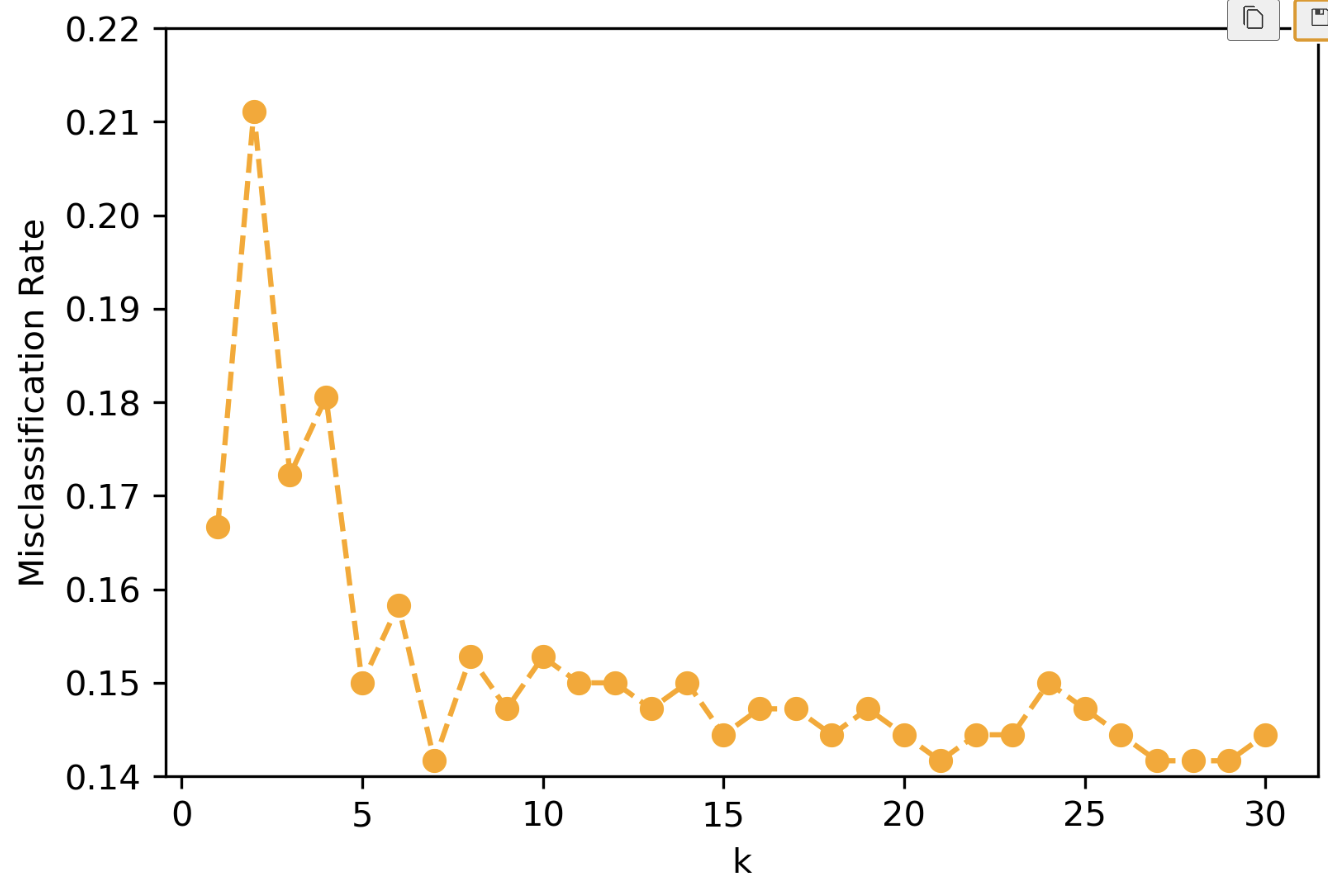

In [ ]:
# 이웃 k 수 1 ~ 30까지 엘보우차트 시각화 (거리 가중치 적용)

# k 수 범위 지정
k_num = range(1, 31)
# k-최근접 이웃 수를 1부터 30까지 순차적으로 증가시키며 실험할 수 있도록 반복 범위 지정함
# 이웃 수가 분류 성능에 어떤 영향을 미치는지를 시각적으로 분석하기 위한 설정임

accuracies = []
# 각 k 값에 따른 테스트셋 오분류율(Misclassification Rate)을 저장할 빈 리스트 생성함
# 추후 엘보우 차트를 그리기 위한 y값으로 사용될 목록임

for k in k_num:
    k_num_model_2 = KNeighborsClassifier(n_neighbors=k, weights='distance')
    # k값을 설정하고 거리 가중치 방식(weights='distance')을 사용하는 KNN 모델 객체 생성함
    # 'distance' 옵션은 가까운 이웃에게 더 큰 가중치를 부여함 → 가까운 이웃의 영향력이 높아짐
    # 이는 이웃 간 거리에 따라 예측 결과가 달라질 수 있도록 조정하는 방식임

    k_num_model_2.fit(x_train, y_train)
    # 학습 데이터를 이용해 모델을 학습시킴 (실제로는 데이터 저장만 수행함)
    # 예측 단계에서 거리 기반 투표가 이루어지도록 준비하는 과정임

    accuracies.append(1 - k_num_model_2.score(x_test, y_test))
    # 테스트셋에 대한 정확도(score)를 1에서 빼서 오분류율로 변환하여 리스트에 저장함
    # k 값이 작거나 클 때 과적합/과소적합이 발생하는지를 오분류율 변화로 확인할 수 있음

# 그래프 옵션 설정
plt.plot(k_num, accuracies, 'o--', color='orange')
# x축을 k값, y축을 오분류율로 설정한 꺾은선 그래프를 그림
# 'o--' 옵션은 점(marker)과 점선을 함께 사용하며, 시계열 추이를 명확하게 표현함
# color='orange'는 시각적으로 잘 구분되도록 색상 지정함

plt.xlabel("k")
# x축 레이블을 'k'로 설정함
# 각 점이 의미하는 것이 k-최근접 이웃 수임을 명확히 표시함

plt.ylabel("Misclassification Rate")
# y축 레이블을 'Misclassification Rate'로 설정함
# 정확도가 아닌 오분류율을 기준으로 성능을 평가하고 있음을 명시함

plt.ylim(0.14, 0.22)
# y축의 범위를 고정하여 그래프 간 비교를 일관되게 유지함
# 범위를 좁게 지정함으로써 성능 차이를 시각적으로 더 강조할 수 있음

plt.show()
# 설정한 그래프를 화면에 출력함
# k 값 변화에 따른 오분류율 곡선을 시각적으로 분석함으로써 최적의 k를 탐색하기 위한 시각화 목적임


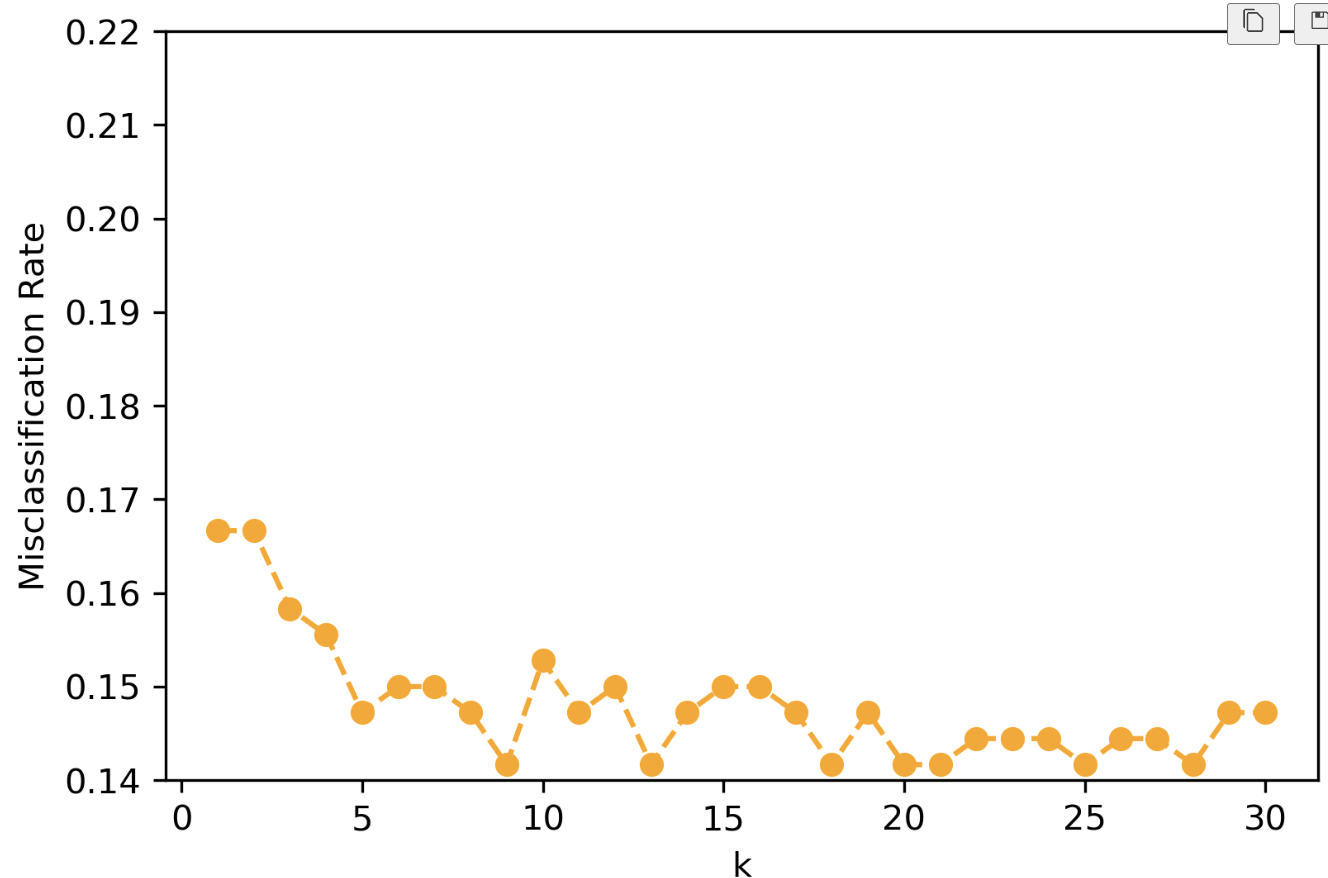

In [ ]:
# 이웃 k 수 1 ~ 200까지 엘보우차트 시각화 (거리 가중치 적용)

# k 수 범위 지정
k_num = range(1, 201)
# k 값을 1부터 200까지 순차적으로 변화시키기 위한 반복 범위 설정
# 고차 범위까지 실험함으로써 학습 데이터 비율 대비 최적 k를 더 정밀하게 탐색하기 위한 목적임

accuracies = []
# 테스트셋에 대한 오분류율을 저장할 빈 리스트 초기화
# 각 k값에 대해 모델이 얼마나 잘 분류하지 못했는지를 저장하고 시각화하기 위한 구조임

for k in k_num:
    k_num_model_2 = KNeighborsClassifier(n_neighbors=k, weights='distance')
    # 현재 반복 중인 k값을 이웃 수로 설정하고 거리 기반 가중치를 적용한 K-NN 모델 생성
    # 가까운 이웃일수록 높은 영향력을 부여하여 예측 시 더 강한 반영이 되도록 설정함

    k_num_model_2.fit(x_train, y_train)
    # 학습 데이터를 기반으로 모델 학습 수행 (실제로는 데이터 저장)
    # 예측 시 거리 계산을 위한 준비 단계임

    accuracies.append(1 - k_num_model_2.score(x_test, y_test))
    # 테스트셋에 대한 정확도를 1에서 빼서 오분류율을 계산함
    # 각 k값에서의 성능 저하 정도를 비교하기 위한 수치로 저장함

# 그래프 옵션 설정
plt.plot(k_num, accuracies, '--', color='orange')
# x축은 k값, y축은 오분류율로 설정하여 꺾은선 그래프를 그림
# '--'는 점선 스타일을 지정하고, color='orange'는 주황색으로 시각화함
# 긴 범위의 k값에 따른 성능 변화를 부드럽게 시각적으로 표현함

plt.xlabel("k")
# x축 레이블을 'k'로 설정하여 이웃 수 변화임을 명확히 표현함

plt.ylabel("Misclassification Rate")
# y축 레이블을 '오분류율'로 설정하여 모델 성능 저하를 의미하는 지표임을 명시함

plt.ylim(0.13, 0.17)
# y축 범위를 고정하여 시각적 변화를 더욱 민감하게 파악할 수 있도록 조절함
# 정확도의 작은 변화도 눈에 띄도록 하는 시각적 강조 설정임

plt.show()
# 그래프를 출력하여 사용자가 최적의 k 값을 시각적으로 탐색할 수 있도록 제공함


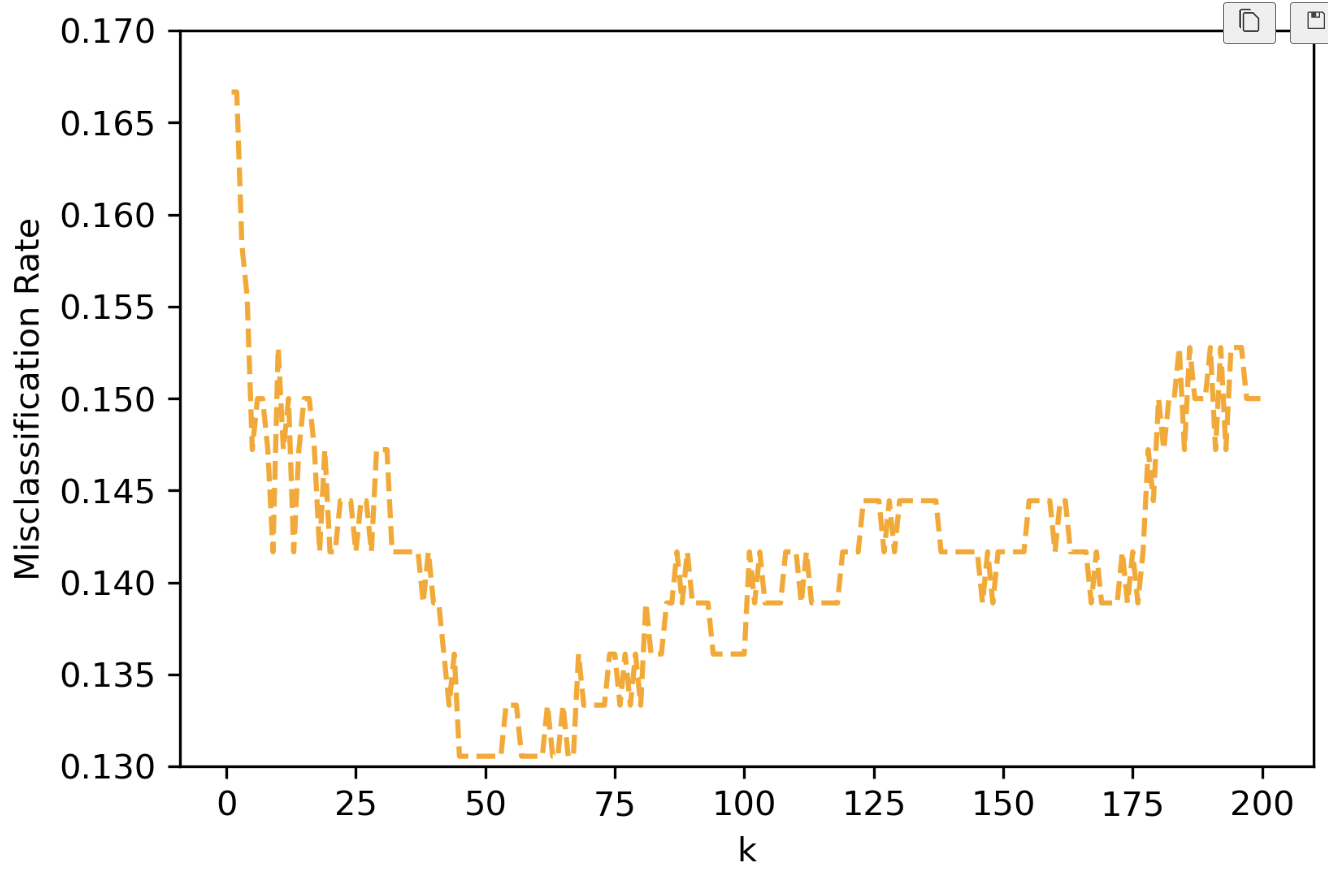

In [ ]:
# 시각화를 위한 차원 축소

# 주성분 개수 설정(2개 설정)
pca = PCA(n_components=2)
# PCA(주성분 분석) 객체를 생성함
# n_components=2는 원래 고차원 데이터를 2개의 주성분(축)으로 축소하겠다는 설정임
# 2차원 공간에 투영함으로써 데이터의 시각화를 가능하게 하기 위한 전처리 단계임

df_pca = pca.fit_transform(x_test)
# 테스트셋(x_test)에 대해 PCA를 수행함
# fit()은 공분산 행렬을 기반으로 주성분 방향을 학습하고,
# transform()은 데이터를 이 주성분 축 위로 투영함
# 결과는 numpy 배열 형식이며 각 샘플이 두 개의 새로운 축(C1, C2)으로 표현됨

# 주성분으로 변형된 테이블 생성
df_pca = pd.DataFrame(data=df_pca, columns=['C1', 'C2'])
# PCA 결과를 pandas DataFrame으로 변환함
# 컬럼명을 'C1'(제1주성분), 'C2'(제2주성분)으로 지정하여 해석을 용이하게 함
# 이후 시각화에서 각 데이터의 위치를 주성분 기준으로 나타낼 수 있도록 구조화함

df_pca.head()
# 변환된 주성분 데이터의 상위 5개 행을 출력함
# 차원 축소가 정상적으로 수행되었는지, 값이 예상 범위에 있는지를 확인하는 절차임

,C1,C2
0,0.802409,0.242069
1,-0.045084,-0.098693
2,-0.318723,0.013834
3,0.032614,0.046625
4,-0.017902,-0.204225


> PCA는 학습셋에 대해 먼저 학습(fit)한 후, 동일한 기준으로 테스트셋에 변환(transform)해야 합니다.
> 

---

### 🔍 이유 설명:

### 1. **PCA도 학습 과정임**

- PCA는 입력 데이터의 **공분산 구조를 학습하여 주성분 축을 정의**합니다.
- 즉, `pca.fit()`은 데이터를 기반으로 새로운 축을 학습하는 "모델 학습"에 해당합니다.
- 테스트셋을 대상으로 `fit`을 수행하면, 모델 평가를 위해 사용되어야 할 테스트 데이터로 **새로운 기준축을 정의하는 셈**이 됩니다 → **데이터 누수(leakage)** 발생

### 2. **일관된 축 유지 필요**

- 모델은 학습셋에서 학습한 피처(또는 주성분)를 기준으로 동작함
- 테스트셋도 반드시 **동일한 주성분 축으로 변환**되어야 올바른 비교가 가능함

```python
# 바람직한 절차
pca = PCA(n_components=2)
pca.fit(x_train)  # 학습셋 기준으로 주성분 축 학습

x_train_pca = pca.transform(x_train)  # 학습셋 변환
x_test_pca = pca.transform(x_test)    # 테스트셋도 동일한 축으로 투영

```

---

### ❌ 만약 테스트셋에 대해 fit을 하면?

- 테스트 데이터로부터 **새로운 주성분 축이 생성**되므로
- 학습 모델이 예측하는 기준과 **다른 피처 공간에서 평가**하게 됨
- 결과적으로 **모델 성능을 정확히 평가할 수 없음**

---

### ✅ 결론

PCA는 **학습셋으로 주성분 방향을 학습(fit)**하고,

**학습셋과 테스트셋 모두 같은 주성분 기준으로 transform**해야

일관된 평가와 일반화 성능 확인이 가능합니다.

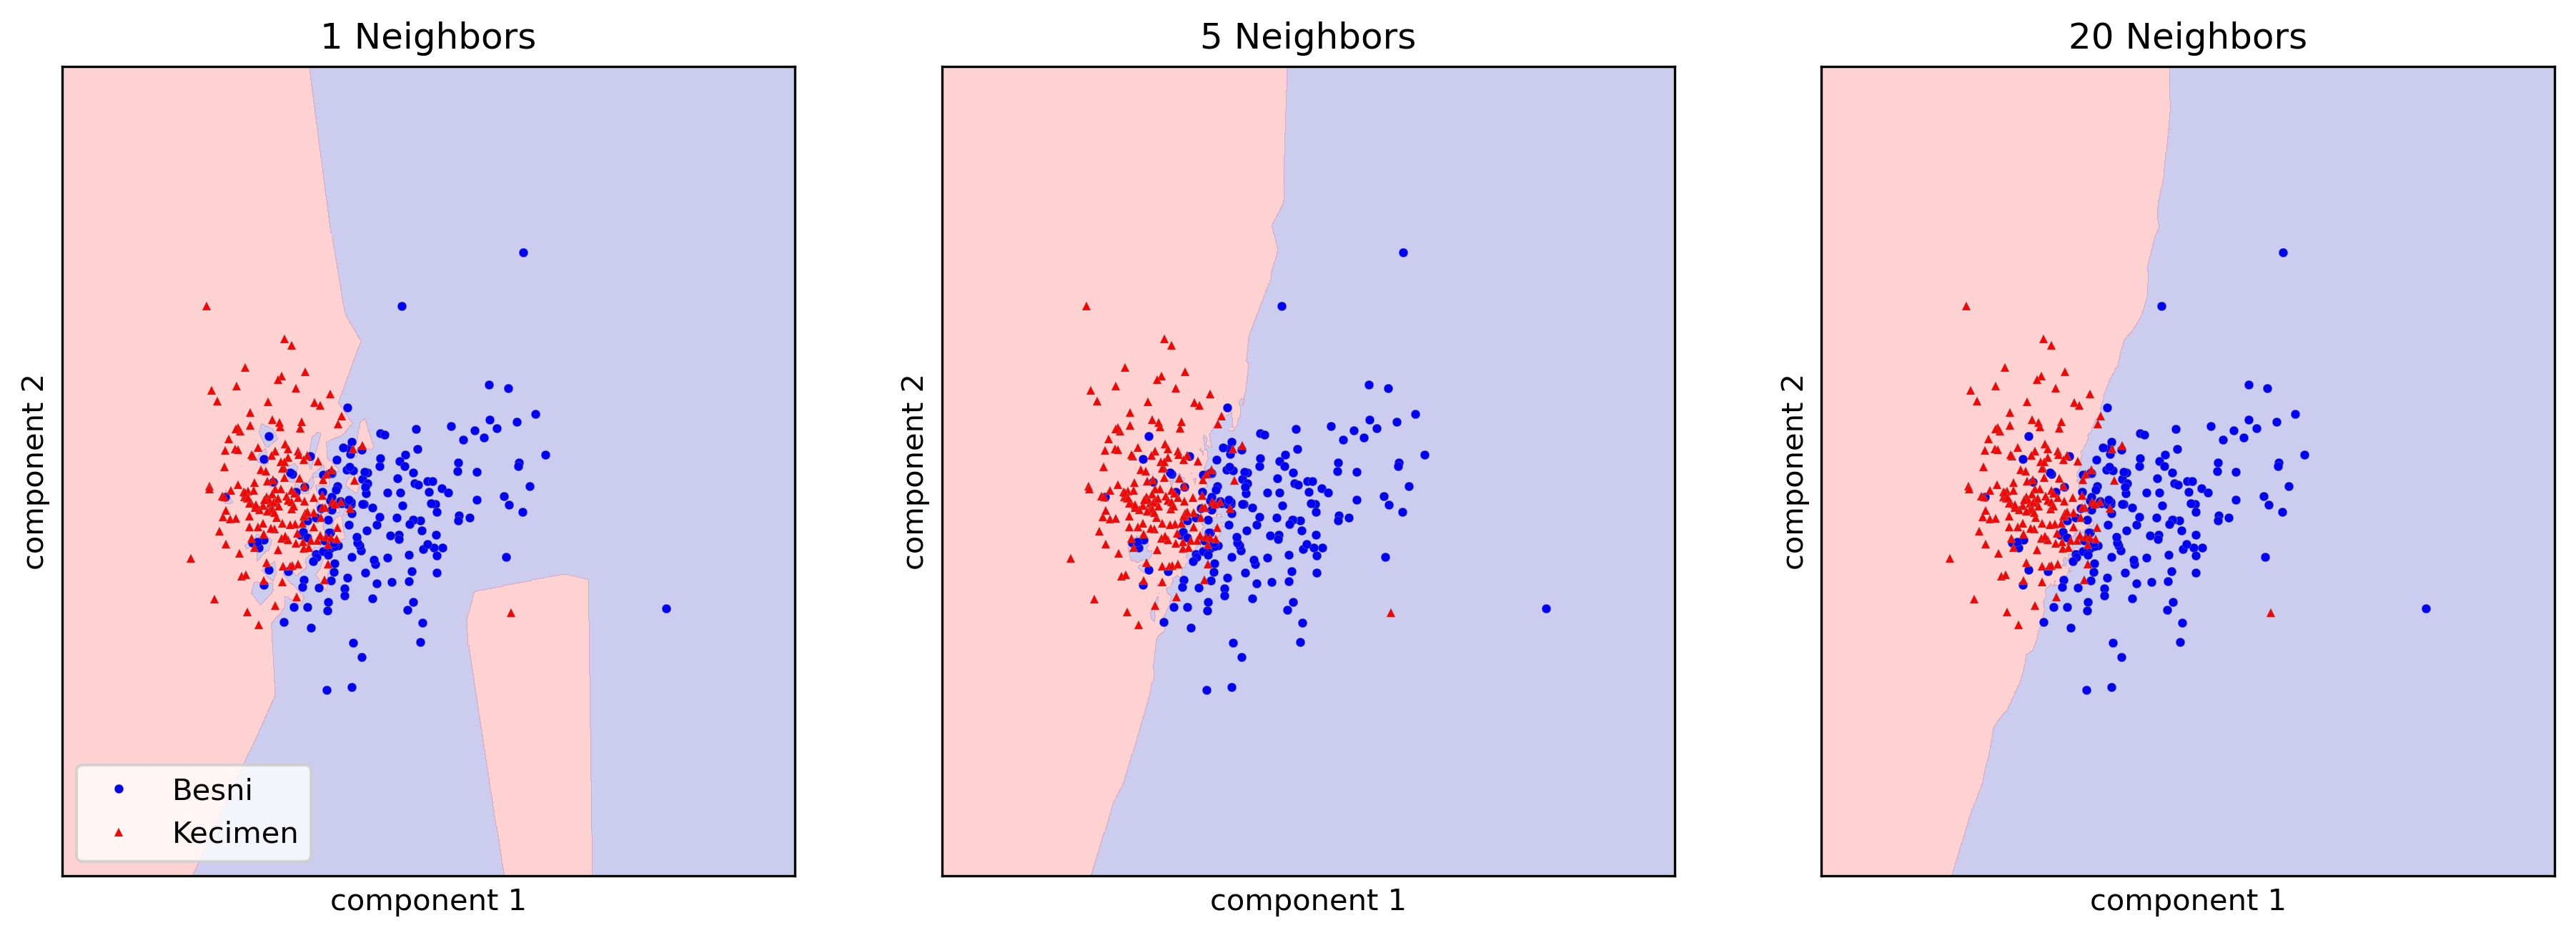

In [ ]:
# 결정 경계선(decision boundary) 시각화 확인

# 독립변수, 종속변수 전처리
df_vsl_x = df_pca.to_numpy()
# 주성분 분석(PCA)을 통해 축소된 테스트셋 입력값(df_pca)을 numpy 배열로 변환함
# mglearn의 시각화 함수가 numpy 형식을 요구하므로 형 변환을 수행함

df_vsl_y = y_test['Class'].to_numpy()
# 테스트셋의 정답 레이블(y_test['Class'])을 numpy 배열로 변환함
# 시각화 시 클래스별 색상 구분 등에 활용하기 위한 목적임

# 그래프 설정
cmap_bold = ListedColormap(['#FF0000', '#00FF00'])
# 각 클래스에 고유한 색상을 지정하기 위한 컬러맵 정의
# #FF0000은 빨간색(클래스 A), #00FF00은 초록색(클래스 B)으로 설정함

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# 1행 3열의 서브플롯을 생성하여 총 3개의 그래프를 나란히 배치함
# 각각의 그래프에 이웃 수(k)를 다르게 설정한 K-NN 모델의 결정 경계를 시각화할 예정임

# 이웃 수 1, 5, 20에 따른 결정경계 시각화
for n_neighbors, ax in zip([1, 5, 20], axes):
    # k 값을 1, 5, 20으로 순차적으로 적용하며 서브플롯(ax)에 대응시키는 반복문 정의

    k_num_model_eg = KNeighborsClassifier(n_neighbors=n_neighbors).fit(df_vsl_x, df_vsl_y)
    # 현재 k값에 해당하는 K-NN 모델을 학습시킴 (입력은 2차원 주성분 축 기준)
    # 이웃 수가 작을수록 모델은 복잡한 결정 경계를 형성하고, 클수록 단순한 경계를 형성함

    mglearn.plots.plot_2d_separator(k_num_model_eg, df_vsl_x, 
                                    fill=True, eps=0.5, ax=ax, alpha=.2)
    # 학습된 모델의 결정 경계를 2차원 평면 상에 시각화함
    # fill=True는 결정 영역을 색상으로 채움, eps는 격자 간격을 조절하는 하이퍼파라미터임
    # alpha는 경계 시각화의 투명도를 의미하며, 값이 낮을수록 배경색이 흐려짐

    mglearn.discrete_scatter(df_vsl_x[:, 0], df_vsl_x[:, 1], 
                             df_vsl_y, markeredgewidth=0.1, 
                             c=['b', 'r'], s=3, ax=ax)
    # 실제 데이터 포인트를 색상별로 흩뿌려서 표시함
    # c 인자는 클래스에 따라 색상을 파란색(b), 빨간색(r)으로 지정함
    # markeredgewidth=0.1은 마커 테두리를 얇게 설정하고, s=3은 점 크기를 작게 지정함

    ax.set_xlabel("component 1")
    # x축 이름을 'component 1'로 설정함 (제1 주성분)

    ax.set_ylabel("component 2")
    # y축 이름을 'component 2'로 설정함 (제2 주성분)

    ax.set_title("{} Neighbors".format(n_neighbors))
    # 각 서브플롯 상단에 현재 k값을 제목으로 표시함

axes[0].legend(loc=3)
# 첫 번째 그래프 좌측 하단(위치 코드 3)에 범례를 표시함
# 클래스별 색상 구분을 사용자에게 시각적으로 전달하기 위한 구성임
